## 📊 Exploratory Data Analysis (EDA) - Facial Emotion Recognition

This notebook handles the initial inspection, extraction, cleanup, and statistical analysis of the facial expression dataset formatted for **YOLOv8**.

* **Project:** Facial Emotion Recognition System
* **Institution:** Politecnico di Torino
* **Supervisors:** Antonio Marceddu & Filippo Gandino

---

#### 📁 1. Automated Dataset Extraction
To bypass Windows filesystem path limits (*Path Too Long* errors) encountered during manual extraction, we leverage Python's `zipfile` module to extract the Roboflow packages directly.

In [1]:
import os
import zipfile

In [2]:
'''
# List containing the exact names of your zip files
zips = [
    "../datasets/Facial emotion recognition.v1i.yolov8.zip",
    "../datasets/facial emotion.v1i.yolov8.zip",
    "../datasets/Facial Emotion.v1i.yolov8_2.zip",
    "../datasets/Human face emotions.v19i.yolov8.zip"
]

for zip_name in zips:
    if os.path.exists(zip_name):
        output_folder = zip_name.replace(".zip", "")
        os.makedirs(output_folder, exist_ok=True)
        
        print(f"Extracting {zip_name} safely...")
        
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            for member in zip_ref.infolist():
                # Obtenemos la ruta que propone el zip
                filename = member.filename
                
                # Si es un archivo de imagen o etiqueta largo, simplificamos el nombre final
                if len(filename) > 100:
                    dir_part, file_part = os.path.split(filename)
                    # Tomamos la extensión (.jpg, .txt, .png)
                    name, ext = os.path.splitext(file_part)
                    # Cortamos el nombre largo a un hash corto único (los últimos 35 caracteres del hash de Roboflow)
                    short_name = name[-35:] if "rf." in name else name[:20]
                    filename = os.path.join(dir_part, f"img_{short_name}{ext}")
                
                # Generamos la ruta completa final en tu sistema
                target_path = os.path.join(output_folder, filename)
                
                # Crear directorios intermedios necesarios (train/images, etc)
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                
                # Si no es un directorio vacío, guardamos el archivo
                if not member.is_dir():
                    with zip_ref.open(member) as source, open(target_path, "wb") as target:
                        target.write(source.read())
            
        print(f"Done! Extracted into '{output_folder}'\n")
    else:
        print(f"File not found: {zip_name}\n")
'''

'\n# List containing the exact names of your zip files\nzips = [\n    "../datasets/Facial emotion recognition.v1i.yolov8.zip",\n    "../datasets/facial emotion.v1i.yolov8.zip",\n    "../datasets/Facial Emotion.v1i.yolov8_2.zip",\n    "../datasets/Human face emotions.v19i.yolov8.zip"\n]\n\nfor zip_name in zips:\n    if os.path.exists(zip_name):\n        output_folder = zip_name.replace(".zip", "")\n        os.makedirs(output_folder, exist_ok=True)\n\n        print(f"Extracting {zip_name} safely...")\n\n        with zipfile.ZipFile(zip_name, \'r\') as zip_ref:\n            for member in zip_ref.infolist():\n                # Obtenemos la ruta que propone el zip\n                filename = member.filename\n\n                # Si es un archivo de imagen o etiqueta largo, simplificamos el nombre final\n                if len(filename) > 100:\n                    dir_part, file_part = os.path.split(filename)\n                    # Tomamos la extensión (.jpg, .txt, .png)\n                    

---

#### 📁 2.  DATASET ANALYSIS (1/4)

In [3]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

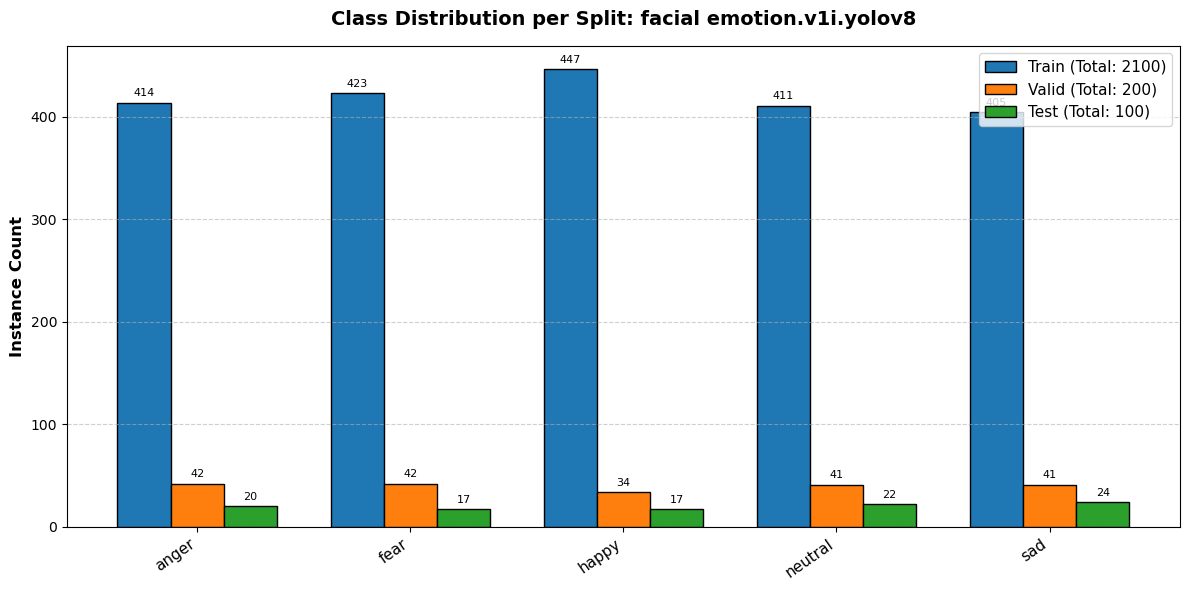

In [4]:
DATASET_PATH = "../datasets/facial emotion.v1i.yolov8"

def get_class_names(dataset_path):
    """Parses data.yaml to extract numerical class ID mappings."""
    yaml_path = os.path.join(dataset_path, "data.yaml")
    class_mapping = {}
    
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            try:
                yaml_data = yaml.safe_load(f)
                if 'names' in yaml_data:
                    if isinstance(yaml_data['names'], list):
                        class_mapping = {i: name for i, name in enumerate(yaml_data['names'])}
                    elif isinstance(yaml_data['names'], dict):
                        class_mapping = {int(k): v for k, v in yaml_data['names'].items()}
            except Exception as e:
                print(f"Error reading data.yaml: {e}")
    return class_mapping

def count_classes_in_split(dataset_path, split_name):
    """Counts instances of each class inside a specific split's labels folder."""
    labels_dir = os.path.join(dataset_path, split_name, "labels")
    counts = Counter()
    
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            class_id = int(parts[0])
                            counts[class_id] += 1
    else:
        print(f"⚠️ Warning: Directory '{labels_dir}' does not exist.")
    return counts

class_map = get_class_names(DATASET_PATH)

if not class_map:
    print(f"Could not load class names. Make sure '{DATASET_PATH}' contains a valid 'data.yaml'.")
else:
    splits = ['train', 'valid', 'test']
    split_counts = {split: count_classes_in_split(DATASET_PATH, split) for split in splits}
    
    all_class_ids = sorted(list(class_map.keys()))
    class_labels = [class_map[cid] for cid in all_class_ids]
    
    train_data = [split_counts['train'][cid] for cid in all_class_ids]
    val_data = [split_counts['valid'][cid] for cid in all_class_ids]
    test_data = [split_counts['test'][cid] for cid in all_class_ids]
    
    x = np.arange(len(class_labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects_train = ax.bar(x - width, train_data, width, label=f'Train (Total: {sum(train_data)})', color='#1f77b4', edgecolor='black')
    rects_val = ax.bar(x, val_data, width, label=f'Valid (Total: {sum(val_data)})', color='#ff7f0e', edgecolor='black')
    rects_test = ax.bar(x + width, test_data, width, label=f'Test (Total: {sum(test_data)})', color='#2ca02c', edgecolor='black')
    
    ax.set_ylabel('Instance Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution per Split: {os.path.basename(DATASET_PATH)}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=11)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.bar_label(rects_train, padding=3, fontsize=8)
    ax.bar_label(rects_val, padding=3, fontsize=8)
    ax.bar_label(rects_test, padding=3, fontsize=8)
    
    plt.tight_layout()
    plt.show()

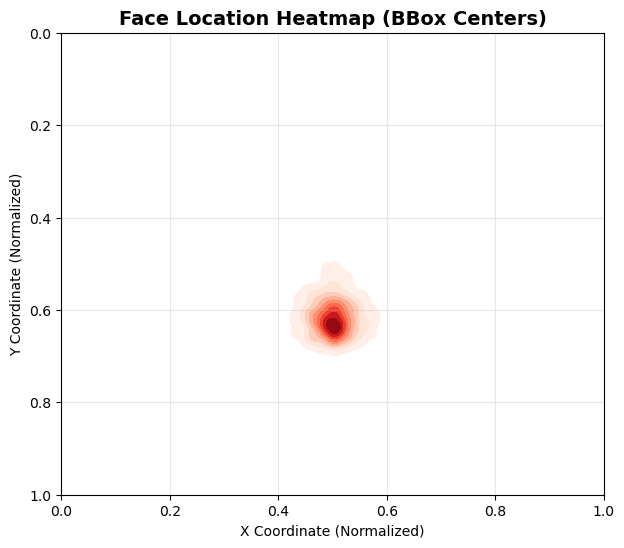

In [5]:
import seaborn as sns

splits = ['train', 'valid', 'test']
x_centers = []
y_centers = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x_centers.append(float(parts[1]))
                            y_centers.append(float(parts[2]))

plt.figure(figsize=(7, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, thresh=0.05)
plt.title('Face Location Heatmap (BBox Centers)', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)')
plt.ylabel('Y Coordinate (Normalized)')
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.grid(True, alpha=0.3)
plt.show()

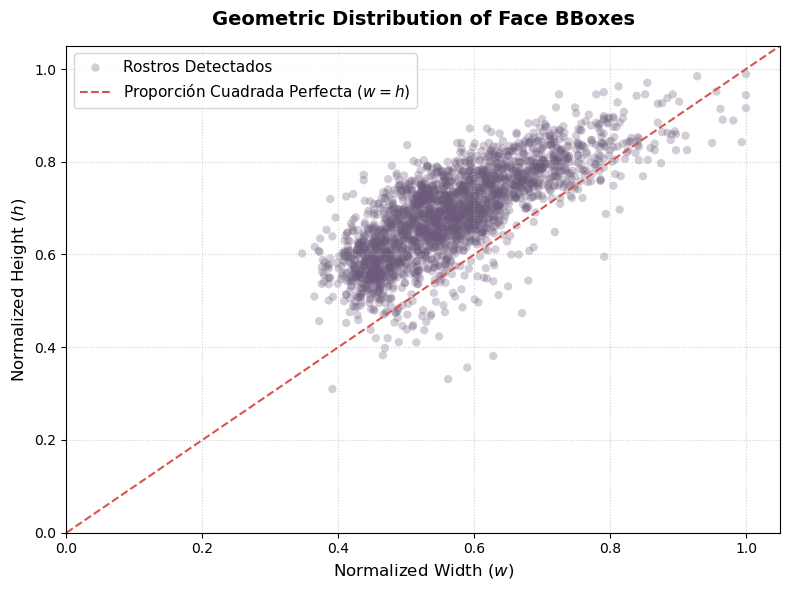

In [6]:
widths = []
heights = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            widths.append(float(parts[3]))
                            heights.append(float(parts[4]))

if len(widths) == 0:
    print("No se encontraron Bounding Boxes. Verifica las rutas de tus carpetas.")
else:
    widths = np.array(widths)
    heights = np.array(heights)
    aspect_ratios = widths / heights

    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.3, color='#6C5B7B', edgecolors='none', label='Rostros Detectados')
    plt.axline((0, 0), slope=1, color='#D9534F', linestyle='--', label='Proporción Cuadrada Perfecta ($w=h$)')
    
    plt.title('Geometric Distribution of Face BBoxes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Normalized Width ($w$)', fontsize=12)
    plt.ylabel('Normalized Height ($h$)', fontsize=12)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

---

#### 📁 2. DATASET ANALYSIS (2/4)

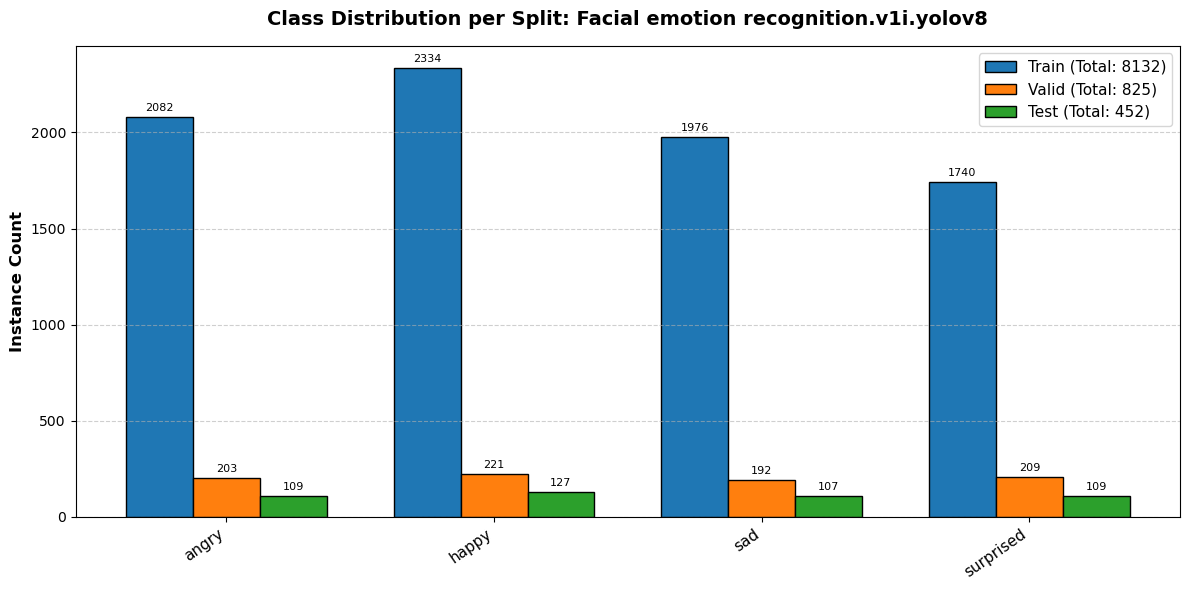

In [7]:
DATASET_PATH = "../datasets/Facial emotion recognition.v1i.yolov8"

class_map = get_class_names(DATASET_PATH)

if not class_map:
    print(f"Could not load class names. Make sure '{DATASET_PATH}' contains a valid 'data.yaml'.")
else:
    splits = ['train', 'valid', 'test']
    split_counts = {split: count_classes_in_split(DATASET_PATH, split) for split in splits}

    all_class_ids = sorted(list(class_map.keys()))
    class_labels = [class_map[cid] for cid in all_class_ids]
    
    train_data = [split_counts['train'][cid] for cid in all_class_ids]
    val_data = [split_counts['valid'][cid] for cid in all_class_ids]
    test_data = [split_counts['test'][cid] for cid in all_class_ids]
    
    x = np.arange(len(class_labels))
    width = 0.25                      
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects_train = ax.bar(x - width, train_data, width, label=f'Train (Total: {sum(train_data)})', color='#1f77b4', edgecolor='black')
    rects_val = ax.bar(x, val_data, width, label=f'Valid (Total: {sum(val_data)})', color='#ff7f0e', edgecolor='black')
    rects_test = ax.bar(x + width, test_data, width, label=f'Test (Total: {sum(test_data)})', color='#2ca02c', edgecolor='black')

    ax.set_ylabel('Instance Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution per Split: {os.path.basename(DATASET_PATH)}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=11)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.bar_label(rects_train, padding=3, fontsize=8)
    ax.bar_label(rects_val, padding=3, fontsize=8)
    ax.bar_label(rects_test, padding=3, fontsize=8)
    
    plt.tight_layout()
    plt.show()

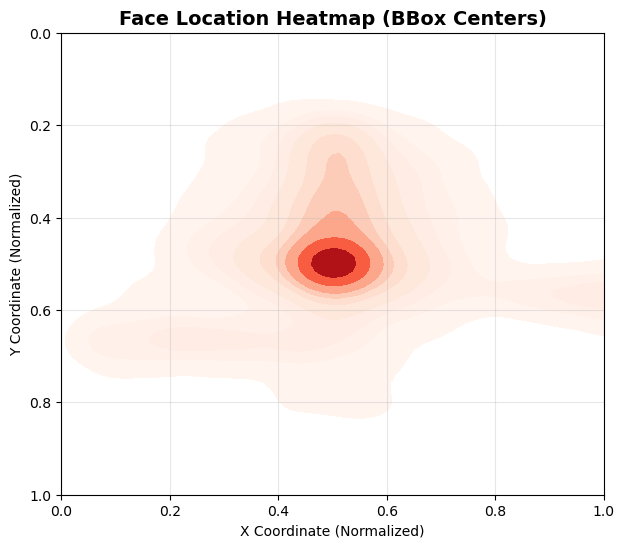

In [8]:
splits = ['train', 'valid', 'test']
x_centers = []
y_centers = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x_centers.append(float(parts[1]))
                            y_centers.append(float(parts[2]))

plt.figure(figsize=(7, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, thresh=0.05)
plt.title('Face Location Heatmap (BBox Centers)', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)')
plt.ylabel('Y Coordinate (Normalized)')
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.grid(True, alpha=0.3)
plt.show()

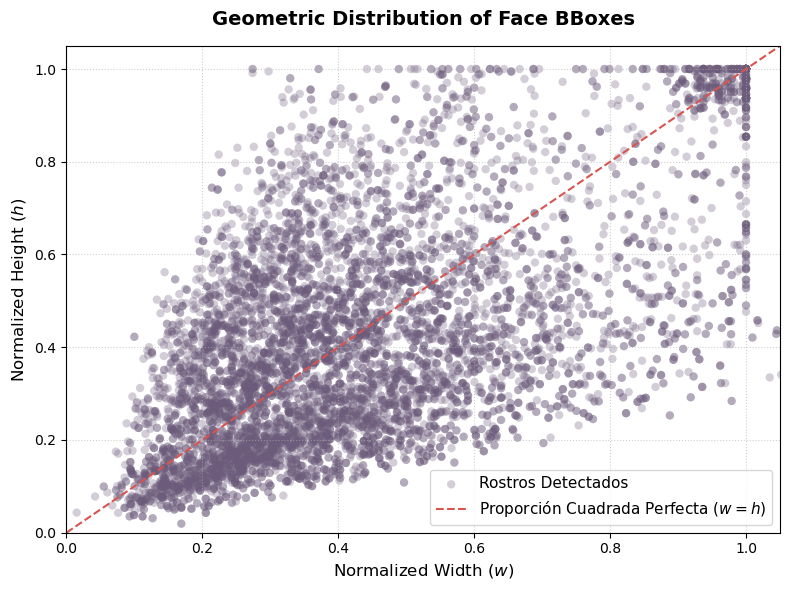

In [9]:
widths = []
heights = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            widths.append(float(parts[3]))
                            heights.append(float(parts[4]))

if len(widths) == 0:
    print("No se encontraron Bounding Boxes. Verifica las rutas de tus carpetas.")
else:
    widths = np.array(widths)
    heights = np.array(heights)
    aspect_ratios = widths / heights

    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.3, color='#6C5B7B', edgecolors='none', label='Rostros Detectados')
    plt.axline((0, 0), slope=1, color='#D9534F', linestyle='--', label='Proporción Cuadrada Perfecta ($w=h$)')
    
    plt.title('Geometric Distribution of Face BBoxes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Normalized Width ($w$)', fontsize=12)
    plt.ylabel('Normalized Height ($h$)', fontsize=12)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

---

#### 📁 2. DATASET ANALYSIS (3/4)

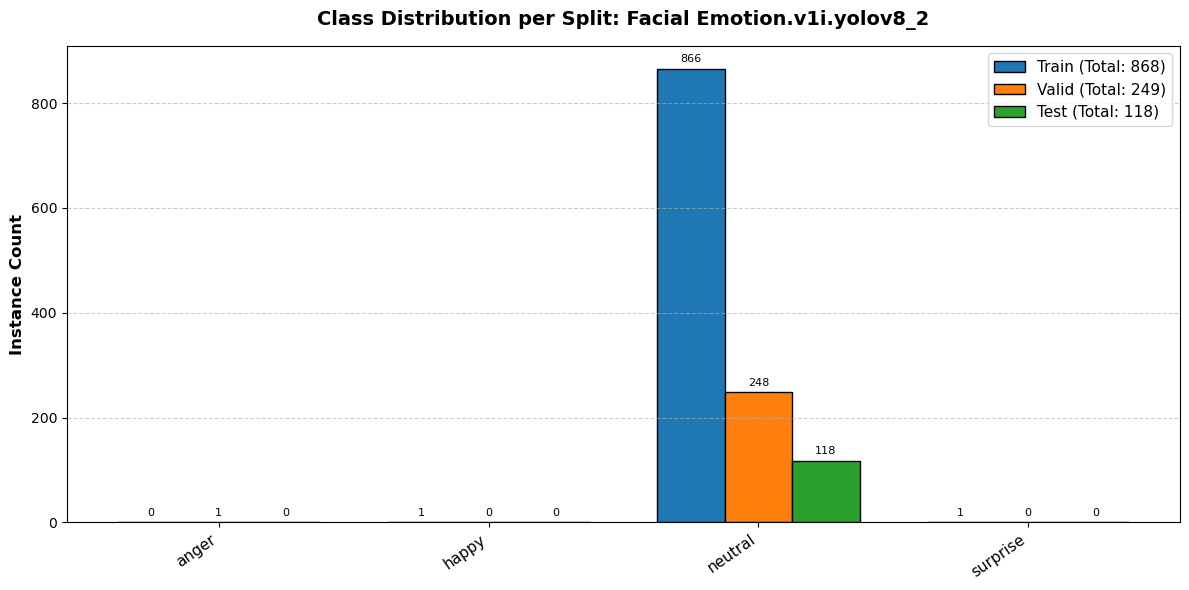

In [10]:
DATASET_PATH = "../datasets/Facial Emotion.v1i.yolov8_2"

class_map = get_class_names(DATASET_PATH)

if not class_map:
    print(f"Could not load class names. Make sure '{DATASET_PATH}' contains a valid 'data.yaml'.")
else:
    splits = ['train', 'valid', 'test']
    split_counts = {split: count_classes_in_split(DATASET_PATH, split) for split in splits}
    
    all_class_ids = sorted(list(class_map.keys()))
    class_labels = [class_map[cid] for cid in all_class_ids]
    
    train_data = [split_counts['train'][cid] for cid in all_class_ids]
    val_data = [split_counts['valid'][cid] for cid in all_class_ids]
    test_data = [split_counts['test'][cid] for cid in all_class_ids]
    
    x = np.arange(len(class_labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects_train = ax.bar(x - width, train_data, width, label=f'Train (Total: {sum(train_data)})', color='#1f77b4', edgecolor='black')
    rects_val = ax.bar(x, val_data, width, label=f'Valid (Total: {sum(val_data)})', color='#ff7f0e', edgecolor='black')
    rects_test = ax.bar(x + width, test_data, width, label=f'Test (Total: {sum(test_data)})', color='#2ca02c', edgecolor='black')
    
    ax.set_ylabel('Instance Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution per Split: {os.path.basename(DATASET_PATH)}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=11)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.bar_label(rects_train, padding=3, fontsize=8)
    ax.bar_label(rects_val, padding=3, fontsize=8)
    ax.bar_label(rects_test, padding=3, fontsize=8)
    
    plt.tight_layout()
    plt.show()

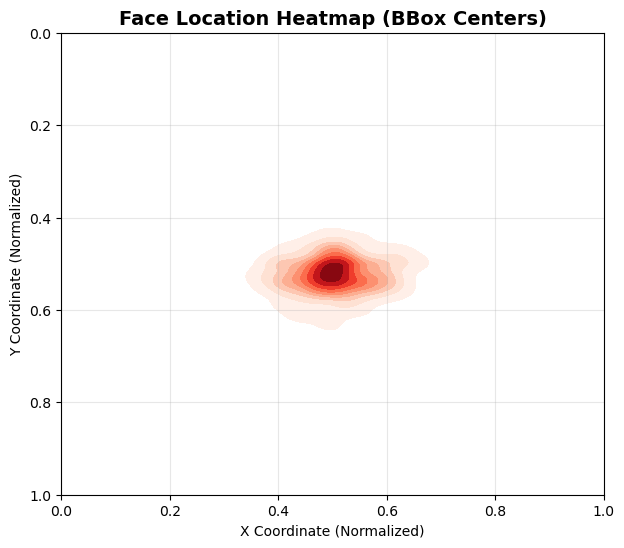

In [11]:
splits = ['train', 'valid', 'test']
x_centers = []
y_centers = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x_centers.append(float(parts[1]))
                            y_centers.append(float(parts[2]))

plt.figure(figsize=(7, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, thresh=0.05)
plt.title('Face Location Heatmap (BBox Centers)', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)')
plt.ylabel('Y Coordinate (Normalized)')
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.grid(True, alpha=0.3)
plt.show()

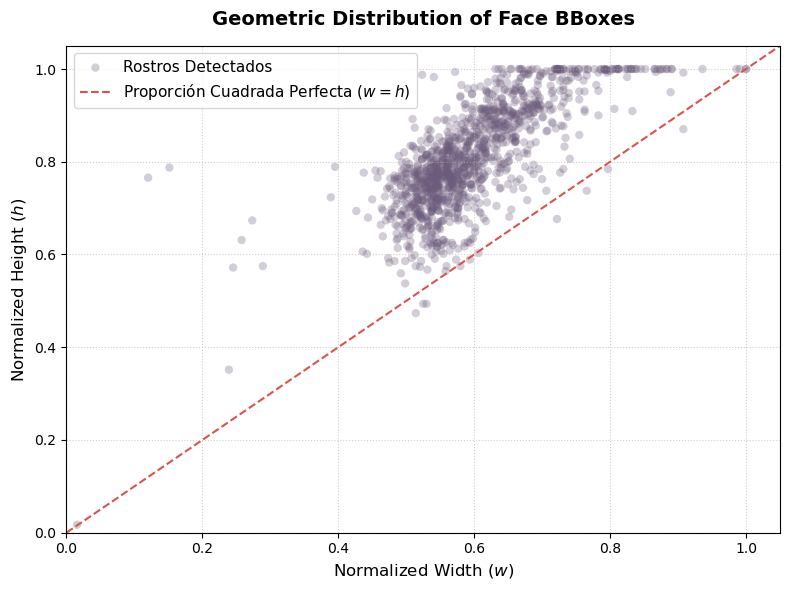

In [12]:
widths = []
heights = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            widths.append(float(parts[3]))
                            heights.append(float(parts[4]))

if len(widths) == 0:
    print("No se encontraron Bounding Boxes. Verifica las rutas de tus carpetas.")
else:
    widths = np.array(widths)
    heights = np.array(heights)
    aspect_ratios = widths / heights

    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.3, color='#6C5B7B', edgecolors='none', label='Rostros Detectados')
    plt.axline((0, 0), slope=1, color='#D9534F', linestyle='--', label='Proporción Cuadrada Perfecta ($w=h$)')
    
    plt.title('Geometric Distribution of Face BBoxes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Normalized Width ($w$)', fontsize=12)
    plt.ylabel('Normalized Height ($h$)', fontsize=12)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

---

#### 📁 2. DATASET ANALYSIS (4/4)

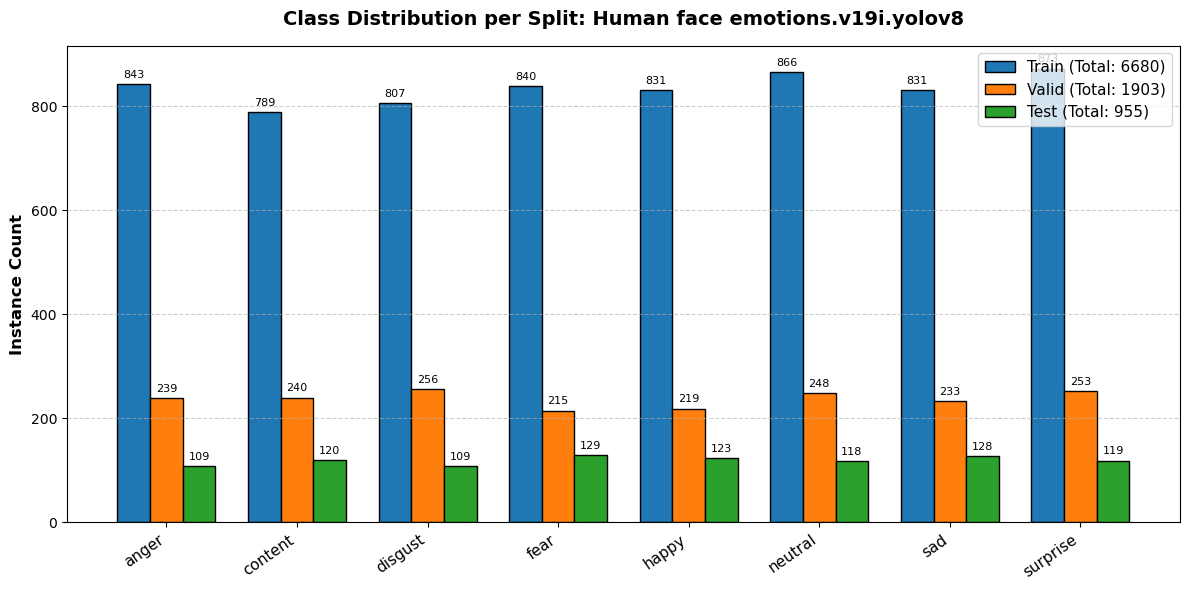

In [13]:
DATASET_PATH = "../datasets/Human face emotions.v19i.yolov8"

class_map = get_class_names(DATASET_PATH)

if not class_map:
    print(f"Could not load class names. Make sure '{DATASET_PATH}' contains a valid 'data.yaml'.")
else:
    splits = ['train', 'valid', 'test']
    split_counts = {split: count_classes_in_split(DATASET_PATH, split) for split in splits}
    
    all_class_ids = sorted(list(class_map.keys()))
    class_labels = [class_map[cid] for cid in all_class_ids]
    
    train_data = [split_counts['train'][cid] for cid in all_class_ids]
    val_data = [split_counts['valid'][cid] for cid in all_class_ids]
    test_data = [split_counts['test'][cid] for cid in all_class_ids]
    
    x = np.arange(len(class_labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects_train = ax.bar(x - width, train_data, width, label=f'Train (Total: {sum(train_data)})', color='#1f77b4', edgecolor='black')
    rects_val = ax.bar(x, val_data, width, label=f'Valid (Total: {sum(val_data)})', color='#ff7f0e', edgecolor='black')
    rects_test = ax.bar(x + width, test_data, width, label=f'Test (Total: {sum(test_data)})', color='#2ca02c', edgecolor='black')
    
    ax.set_ylabel('Instance Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution per Split: {os.path.basename(DATASET_PATH)}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=11)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.bar_label(rects_train, padding=3, fontsize=8)
    ax.bar_label(rects_val, padding=3, fontsize=8)
    ax.bar_label(rects_test, padding=3, fontsize=8)
    
    plt.tight_layout()
    plt.show()

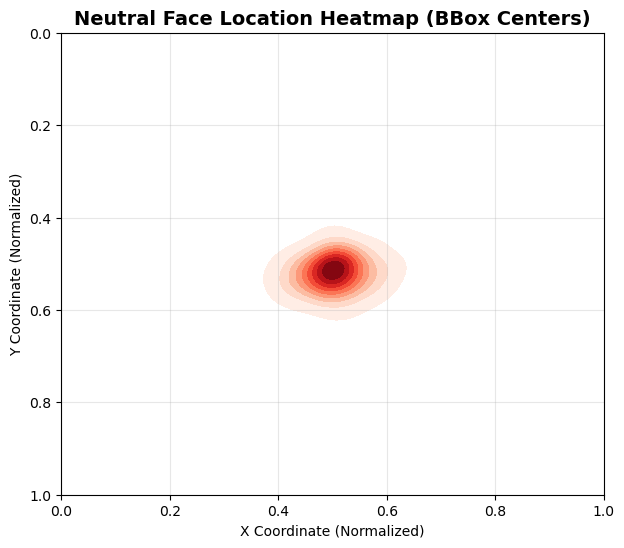

In [14]:
splits = ['train', 'valid', 'test']
x_centers = []
y_centers = []

NEUTRAL_CLASS_ID = 0  

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            # 1. Filtramos por la columna de la clase (parts[0])
                            class_id = int(parts[0])
                            if class_id == NEUTRAL_CLASS_ID:
                                x_centers.append(float(parts[1]))
                                y_centers.append(float(parts[2]))

plt.figure(figsize=(7, 6))

sns.kdeplot(
    x=x_centers, 
    y=y_centers, 
    cmap="Reds", 
    fill=True, 
    thresh=0.05, 
    bw_adjust=1.5
)

plt.title('Neutral Face Location Heatmap (BBox Centers)', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)')
plt.ylabel('Y Coordinate (Normalized)')
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.grid(True, alpha=0.3)
plt.show()

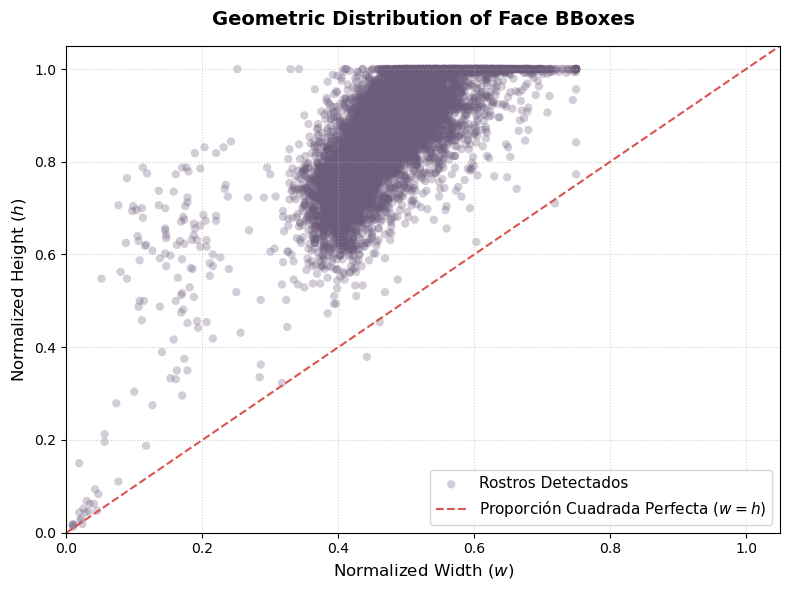

In [15]:
widths = []
heights = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            widths.append(float(parts[3]))
                            heights.append(float(parts[4]))

if len(widths) == 0:
    print("No se encontraron Bounding Boxes. Verifica las rutas de tus carpetas.")
else:
    widths = np.array(widths)
    heights = np.array(heights)
    aspect_ratios = widths / heights

    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.3, color='#6C5B7B', edgecolors='none', label='Rostros Detectados')
    plt.axline((0, 0), slope=1, color='#D9534F', linestyle='--', label='Proporción Cuadrada Perfecta ($w=h$)')
    
    plt.title('Geometric Distribution of Face BBoxes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Normalized Width ($w$)', fontsize=12)
    plt.ylabel('Normalized Height ($h$)', fontsize=12)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


---

#### 📁 3. Creation of a new dataset

In [16]:
import shutil

DATASET_PATH = "../datasets/"
COMBINED_DIR = os.path.join(DATASET_PATH, "combined_dataset")
splits = ['train', 'valid', 'test']

PATH_DATASET_1 = os.path.join(DATASET_PATH, "facial emotion.v1i.yolov8")
PATH_DATASET_2 = os.path.join(DATASET_PATH, "Facial emotion recognition.v1i.yolov8")
PATH_DATASET_3 = os.path.join(DATASET_PATH, "Facial Emotion.v1i.yolov8_2")
PATH_DATASET_4 = os.path.join(DATASET_PATH, "Human face emotions.v19i.yolov8")

for split in splits:
    os.makedirs(os.path.join(COMBINED_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(COMBINED_DIR, split, "labels"), exist_ok=True)

# Dataset 1: Extract Neutral and Fear
MAP_DATASET_1 = {
    3: 4,
    1: 5
}

# Dataset 3: Extract Neutral
MAP_DATASET_3 = {
    0: 4
}

# Dataset 4: Extract Fear (and Neutral if available)
MAP_DATASET_4 = {
    5: 4,
    3: 5
}


def inject_dataset_samples(src_dataset_path, mapping_dict, dataset_prefix):
    """
    Parses source annotations, remaps specific targeted classes to the 
    global ontology, and copies matching image-label pairs into the split.
    """
    if not os.path.exists(src_dataset_path):
        print(f"Warning: Source path {src_dataset_path} not found. Skipping...")
        return

    print(f"Injecting targeted classes from {dataset_prefix}...")
    
    for split in splits:
        labels_src_dir = os.path.join(src_dataset_path, split, "labels")
        images_src_dir = os.path.join(src_dataset_path, split, "images")
        
        if not os.path.exists(labels_src_dir):
            continue
            
        for file in os.listdir(labels_src_dir):
            if file.endswith('.txt'):
                src_label_path = os.path.join(labels_src_dir, file)
                new_lines = []
                
                with open(src_label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            local_class = int(parts[0])
                            
                            # If the parsed class is a missing target, remap it
                            if local_class in mapping_dict:
                                global_class = mapping_dict[local_class]
                                # Reconstruct the bounding box row vector
                                new_line = f"{global_class} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n"
                                new_lines.append(new_line)
                
                # If target classes were successfully matched, transfer the files
                if new_lines:
                    # Prefix filenames to guarantee uniqueness and avoid overwrites
                    new_file_name = f"{dataset_prefix}_{file}"
                    dest_label_path = os.path.join(COMBINED_DIR, split, "labels", new_file_name)
                    
                    with open(dest_label_path, 'w') as f:
                        f.writelines(new_lines)
                    
                    # Locate and clone the synchronized image file
                    for ext in ['.jpg', '.jpeg', '.png']:
                        img_file = file.replace('.txt', ext)
                        src_img_path = os.path.join(images_src_dir, img_file)
                        if os.path.exists(src_img_path):
                            dest_img_path = os.path.join(COMBINED_DIR, split, "images", f"{dataset_prefix}_{img_file}")
                            shutil.copy(src_img_path, dest_img_path)
                            break


# Clone Dataset 2 directly as the structural base
print("Initializing baseline with Dataset 2...")
for split in splits:
    src_img_base = os.path.join(PATH_DATASET_2, split, "images")
    src_lbl_base = os.path.join(PATH_DATASET_2, split, "labels")
    
    if os.path.exists(src_img_base):
        for f in os.listdir(src_img_base):
            shutil.copy(os.path.join(src_img_base, f), os.path.join(COMBINED_DIR, split, "images", f))
    if os.path.exists(src_lbl_base):
        for f in os.listdir(src_lbl_base):
            shutil.copy(os.path.join(src_lbl_base, f), os.path.join(COMBINED_DIR, split, "labels", f))

# Run selective injection on donor sets to solve class imbalance
inject_dataset_samples(PATH_DATASET_1, MAP_DATASET_1, "ds1")
inject_dataset_samples(PATH_DATASET_3, MAP_DATASET_3, "ds3")
inject_dataset_samples(PATH_DATASET_4, MAP_DATASET_4, "ds4")

# Create data.yaml for YOLO training
yaml_content = """
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['angry', 'happy', 'sad', 'surprise', 'neutral', 'fear']
"""

yaml_path = os.path.join(COMBINED_DIR, "data.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("File 'data.yaml' created successfully.")

readme_content = """# Consolidated Facial Expression Dataset (Neuromorphic Computing Lab)

## Origin and Motivation
This dataset was curated following the professor's feedback to address critical limitations in the baseline models:
1. **Dataset 2 (Base):** Contained high class diversity but completely lacked the crucial `neutrality` baseline and the `fear` class.
2. **Dataset 1, 3 & 4:** Used as donor repositories to inject missing samples of `neutral` and `fear` expressions.

## Global Class Mapping (Ontology)
To prevent label collision and ensure consistency across repositories, all source annotations (`.txt` files) were mapped to the following global structure:
- `0`: angry (from Dataset 2)
- `1`: happy (from Dataset 2)
- `2`: sad (from Dataset 2)
- `3`: surprise (from Dataset 2)
- `4`: neutral (Injected from Dataset 1, 3, 4)
- `5`: fear (Injected from Dataset 1 and Dataset 4)

## Preprocessing Pipeline
- Original bounding boxes were preserved.
- File names were prefixed with `ds1_`, `ds3_`, and `ds4_` to avoid filename overwrites during the injection process.
"""

readme_path = os.path.join(COMBINED_DIR, "README.md")
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("File 'README.md' created automatically.")
print("DATASET CONSOLIDATION COMPLETED SUCCESSFULLY!")

Initializing baseline with Dataset 2...
Injecting targeted classes from ds1...
Injecting targeted classes from ds3...
Injecting targeted classes from ds4...
File 'data.yaml' created successfully.
File 'README.md' created automatically.
DATASET CONSOLIDATION COMPLETED SUCCESSFULLY!


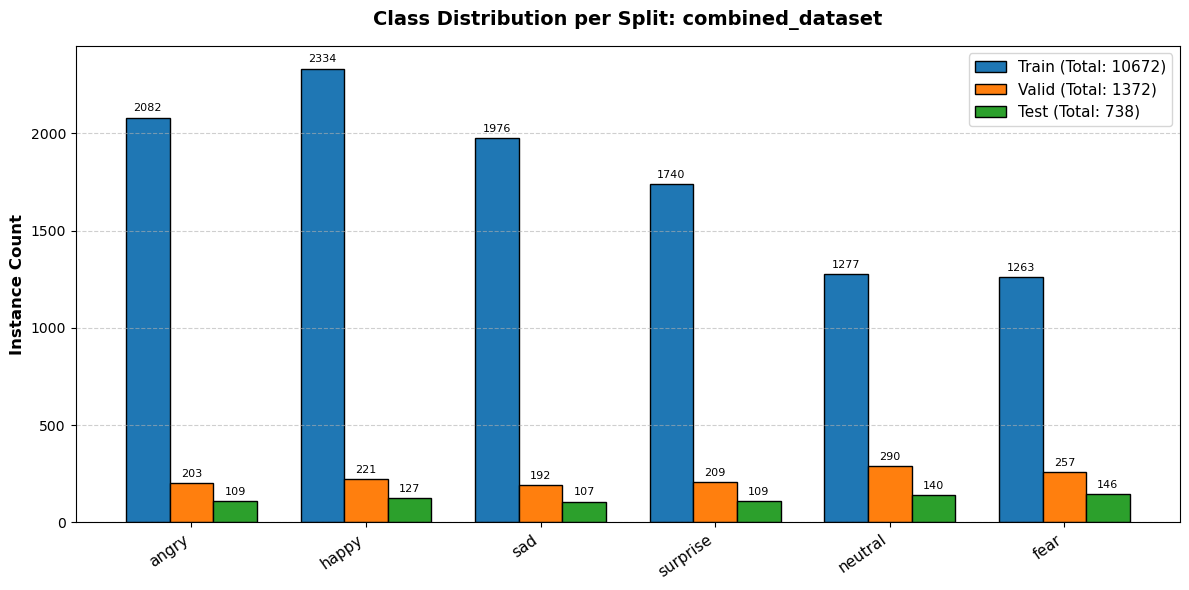

In [17]:
DATASET_PATH = "../datasets/combined_dataset"

class_map = get_class_names(DATASET_PATH)

if not class_map:
    print(f"Could not load class names. Make sure '{DATASET_PATH}' contains a valid 'data.yaml'.")
else:
    splits = ['train', 'valid', 'test']
    split_counts = {split: count_classes_in_split(DATASET_PATH, split) for split in splits}
    
    all_class_ids = sorted(list(class_map.keys()))
    class_labels = [class_map[cid] for cid in all_class_ids]
    
    train_data = [split_counts['train'][cid] for cid in all_class_ids]
    val_data = [split_counts['valid'][cid] for cid in all_class_ids]
    test_data = [split_counts['test'][cid] for cid in all_class_ids]
    
    x = np.arange(len(class_labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects_train = ax.bar(x - width, train_data, width, label=f'Train (Total: {sum(train_data)})', color='#1f77b4', edgecolor='black')
    rects_val = ax.bar(x, val_data, width, label=f'Valid (Total: {sum(val_data)})', color='#ff7f0e', edgecolor='black')
    rects_test = ax.bar(x + width, test_data, width, label=f'Test (Total: {sum(test_data)})', color='#2ca02c', edgecolor='black')
    
    ax.set_ylabel('Instance Count', fontsize=12, fontweight='bold')
    ax.set_title(f'Class Distribution per Split: {os.path.basename(DATASET_PATH)}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=11)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.bar_label(rects_train, padding=3, fontsize=8)
    ax.bar_label(rects_val, padding=3, fontsize=8)
    ax.bar_label(rects_test, padding=3, fontsize=8)
    
    plt.tight_layout()
    plt.show()

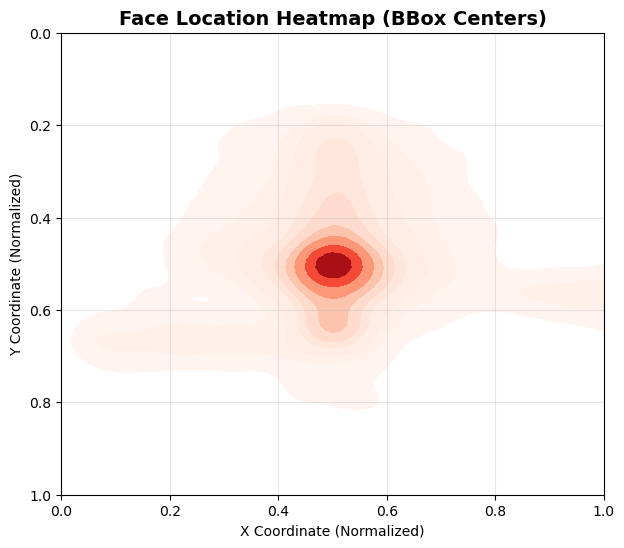

In [18]:
splits = ['train', 'valid', 'test']
x_centers = []
y_centers = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            x_centers.append(float(parts[1]))
                            y_centers.append(float(parts[2]))

plt.figure(figsize=(7, 6))
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, thresh=0.05)
plt.title('Face Location Heatmap (BBox Centers)', fontsize=14, fontweight='bold')
plt.xlabel('X Coordinate (Normalized)')
plt.ylabel('Y Coordinate (Normalized)')
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.grid(True, alpha=0.3)
plt.show()

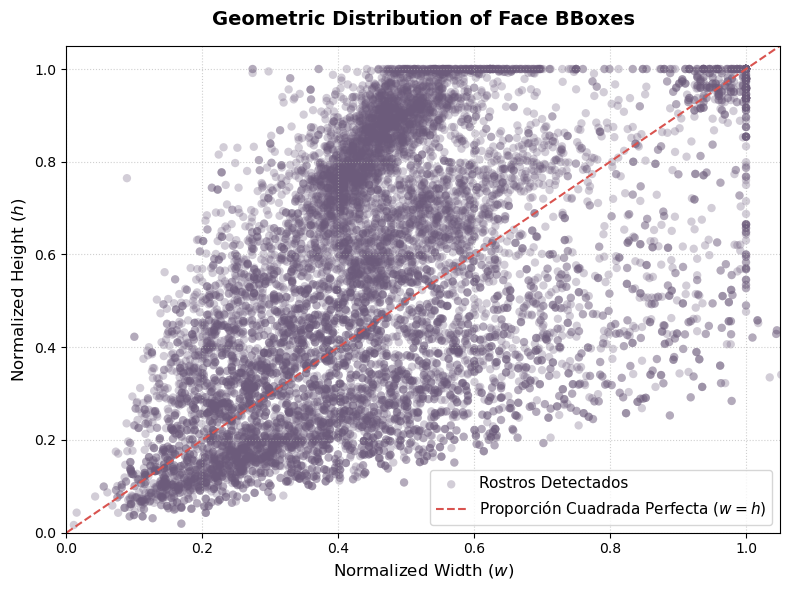

In [19]:
widths = []
heights = []

for split in splits:
    labels_dir = os.path.join(DATASET_PATH, split, "labels")
    if os.path.exists(labels_dir):
        for file in os.listdir(labels_dir):
            if file.endswith('.txt'):
                with open(os.path.join(labels_dir, file), 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            widths.append(float(parts[3]))
                            heights.append(float(parts[4]))

if len(widths) == 0:
    print("❌ No se encontraron Bounding Boxes. Verifica las rutas de tus carpetas.")
else:
    widths = np.array(widths)
    heights = np.array(heights)
    aspect_ratios = widths / heights

    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.3, color='#6C5B7B', edgecolors='none', label='Rostros Detectados')
    plt.axline((0, 0), slope=1, color='#D9534F', linestyle='--', label='Proporción Cuadrada Perfecta ($w=h$)')
    
    plt.title('Geometric Distribution of Face BBoxes', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Normalized Width ($w$)', fontsize=12)
    plt.ylabel('Normalized Height ($h$)', fontsize=12)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()